# 04 - Tree-Based Models

**Goal:** Learn tree models, understand feature importance, and explore the bias-variance tradeoff.

**Key concept:** A decision tree splits data into groups by asking yes/no questions about features. "Is xG_rolling_3 > 0.5?" → left branch (high xG players) vs right branch. Each leaf predicts the average points of the training examples that ended up there.

A **random forest** trains many trees on random subsets of the data and averages their predictions — this reduces overfitting.

In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'prediction'))

from prediction.src.evaluation import evaluate_model, plot_predictions_vs_actual, plot_residuals

DATA_DIR = os.path.join(PROJECT_ROOT, 'prediction', 'data')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_parquet(os.path.join(DATA_DIR, 'features_all.parquet'))
with open(os.path.join(DATA_DIR, 'feature_columns.json')) as f:
    FEATURE_COLS = json.load(f)

TARGET = 'total_points'

# Same temporal split as Phase 3
max_gw = df['round'].max()
split_gw = int(max_gw * 0.75)
train = df[df['round'] <= split_gw]
test = df[df['round'] > split_gw]
X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]

# Load Phase 3 results for comparison
prev_results = pd.read_csv(os.path.join(DATA_DIR, 'results_phase3.csv'), index_col=0)
results = prev_results.to_dict('index')

print(f'Train: {len(train):,} rows (GW 1-{split_gw})')
print(f'Test:  {len(test):,} rows (GW {split_gw+1}-{max_gw})')

Train: 6,445 rows (GW 1-23)
Test:  2,256 rows (GW 24-31)


## 1. Decision Tree — Overfitting Demonstration

An unconstrained decision tree will memorize the training data perfectly (train R2 ~ 1.0) but perform terribly on test data. This is **overfitting** — the model learned noise, not signal.

In [2]:
# Unrestricted tree — will overfit
dt_full = DecisionTreeRegressor(random_state=42)
dt_full.fit(X_train, y_train)

train_metrics = evaluate_model(y_train, dt_full.predict(X_train))
test_metrics = evaluate_model(y_test, dt_full.predict(X_test))

print('Unrestricted Decision Tree:')
print(f'  Train — MAE: {train_metrics["MAE"]:.3f}, R2: {train_metrics["R2"]:.3f}')
print(f'  Test  — MAE: {test_metrics["MAE"]:.3f}, R2: {test_metrics["R2"]:.3f}')
print(f'  Tree depth: {dt_full.get_depth()}, leaves: {dt_full.get_n_leaves()}')
print(f'\n  Train R2 near 1.0 + low test R2 = classic overfitting')

Unrestricted Decision Tree:
  Train — MAE: 0.000, R2: 1.000
  Test  — MAE: 3.173, R2: -1.448
  Tree depth: 35, leaves: 3123

  Train R2 near 1.0 + low test R2 = classic overfitting


## 2. Pruning: Controlling Tree Complexity

`max_depth` limits how deep the tree can grow. Shallower = simpler = less overfitting but potentially underfitting.

In [3]:
depths = [3, 5, 7, 10, 15, 20, None]
depth_results = []

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    
    train_m = evaluate_model(y_train, dt.predict(X_train))
    test_m = evaluate_model(y_test, dt.predict(X_test))
    
    depth_results.append({
        'max_depth': str(d) if d else 'None',
        'train_MAE': train_m['MAE'],
        'test_MAE': test_m['MAE'],
        'train_R2': train_m['R2'],
        'test_R2': test_m['R2'],
        'n_leaves': dt.get_n_leaves()
    })

depth_df = pd.DataFrame(depth_results)
print(depth_df.to_string(index=False))

max_depth  train_MAE  test_MAE  train_R2   test_R2  n_leaves
        3   2.119797  2.131815  0.068575  0.046438         8
        5   2.062455  2.201099  0.121241 -0.009292        30
        7   1.940630  2.266919  0.208331 -0.120807        96
       10   1.628782  2.601297  0.399549 -0.696747       347
       15   0.934092  2.968051  0.715914 -1.203770      1215
       20   0.356517  3.102420  0.915917 -1.398176      2277
     None   0.000000  3.173316  1.000000 -1.448477      3123


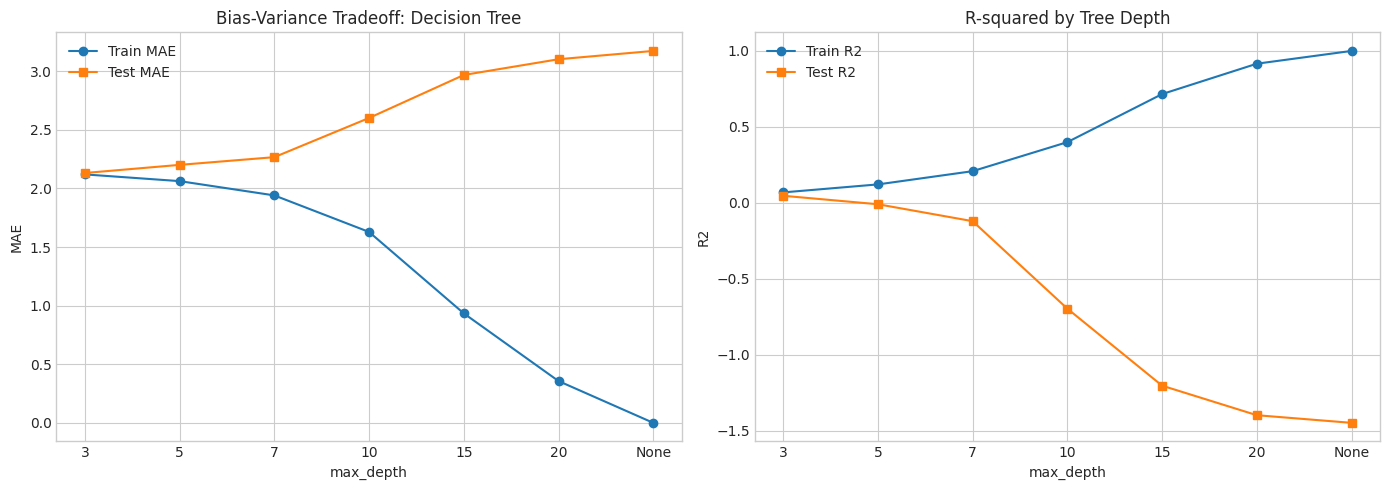

The "sweet spot" is where test metrics are best — train keeps improving but test plateaus or worsens.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = range(len(depth_df))
axes[0].plot(x_pos, depth_df['train_MAE'], 'o-', label='Train MAE')
axes[0].plot(x_pos, depth_df['test_MAE'], 's-', label='Test MAE')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(depth_df['max_depth'])
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('MAE')
axes[0].set_title('Bias-Variance Tradeoff: Decision Tree')
axes[0].legend()

axes[1].plot(x_pos, depth_df['train_R2'], 'o-', label='Train R2')
axes[1].plot(x_pos, depth_df['test_R2'], 's-', label='Test R2')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(depth_df['max_depth'])
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('R2')
axes[1].set_title('R-squared by Tree Depth')
axes[1].legend()

plt.tight_layout()
plt.show()

print('The "sweet spot" is where test metrics are best — train keeps improving but test plateaus or worsens.')

## 3. Random Forest

A random forest trains many decision trees, each on a random subset of rows (bagging) and features. The final prediction is the average across all trees.

**Why it works:** Individual trees overfit differently. Averaging cancels out the noise, keeping the signal.

In [5]:
rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=10,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred_train = rf.predict(X_train)
rf_pred_test = rf.predict(X_test)

rf_train = evaluate_model(y_train, rf_pred_train)
rf_test = evaluate_model(y_test, rf_pred_test)
results['Random Forest'] = rf_test

print('Random Forest (100 trees, max_depth=15):')
print(f'  Train — MAE: {rf_train["MAE"]:.3f}, R2: {rf_train["R2"]:.3f}')
print(f'  Test  — MAE: {rf_test["MAE"]:.3f}, R2: {rf_test["R2"]:.3f}')

Random Forest (100 trees, max_depth=15):
  Train — MAE: 1.613, R2: 0.441
  Test  — MAE: 2.238, R2: 0.051


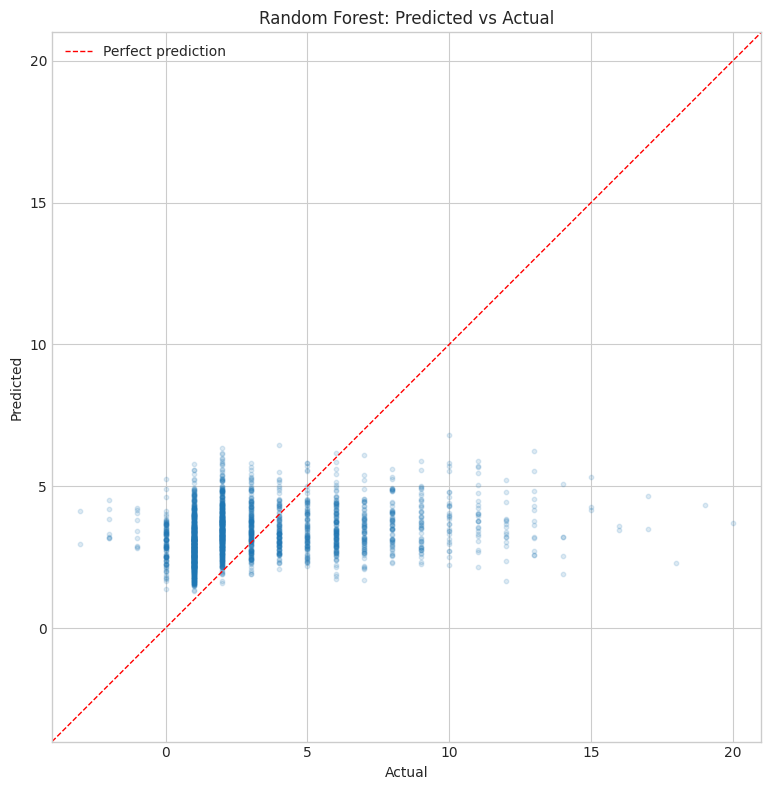

In [6]:
fig = plot_predictions_vs_actual(y_test, rf_pred_test, 'Random Forest: Predicted vs Actual')
plt.show()

## 4. Feature Importance

Random forests provide **feature importance** — how much each feature reduces prediction error across all trees. Compare this to the correlation analysis from EDA.

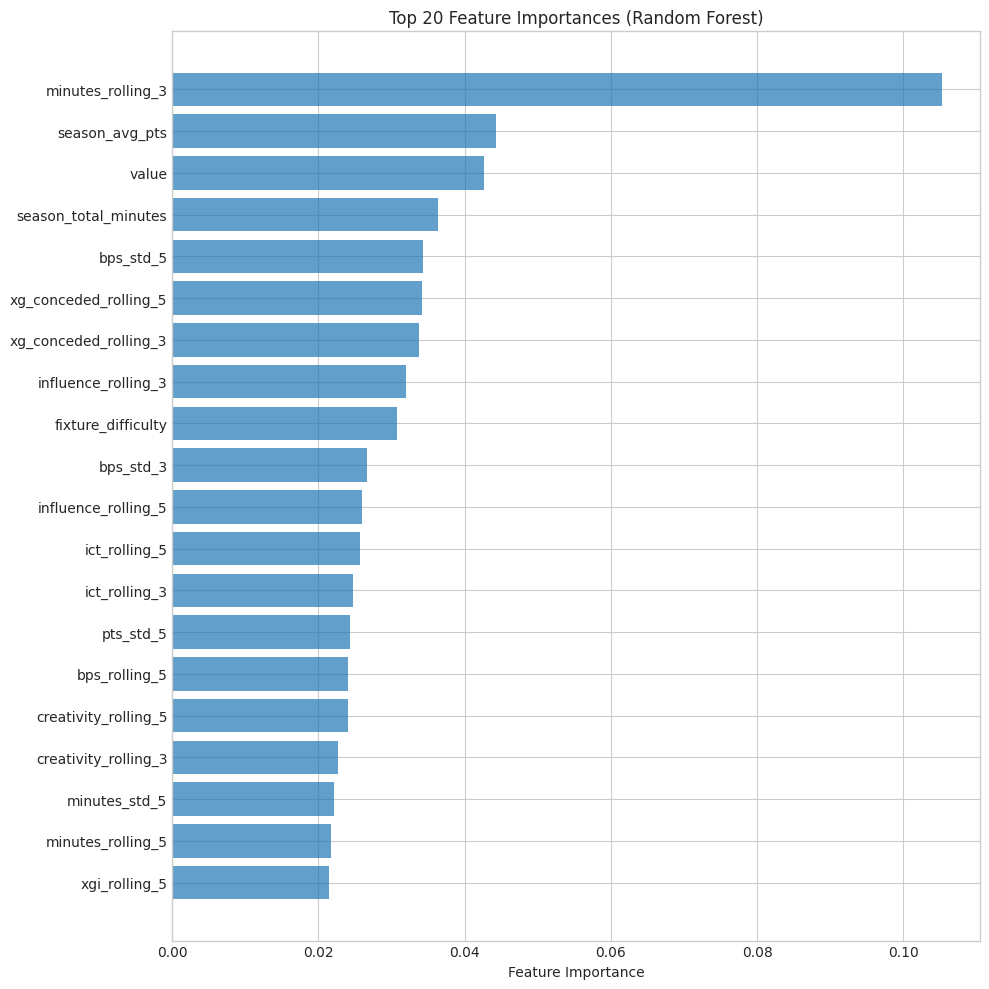


Top 10 features:
              feature  importance
    minutes_rolling_3    0.105223
       season_avg_pts    0.044317
                value    0.042627
 season_total_minutes    0.036412
            bps_std_5    0.034291
xg_conceded_rolling_5    0.034191
xg_conceded_rolling_3    0.033766
  influence_rolling_3    0.031958
   fixture_difficulty    0.030711
            bps_std_3    0.026608


In [7]:
importances = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
top_20 = importances.head(20)
ax.barh(range(len(top_20)), top_20['importance'].values, alpha=0.7)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'].values)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Feature Importances (Random Forest)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(importances.head(10).to_string(index=False))

## 5. Per-Position Models vs Unified Model

The plan calls for separate models per position. Let's test whether this actually helps.

In [8]:
print(f'{"Position":<15s} {"Unified MAE":>12s} {"Separate MAE":>13s} {"Improvement":>12s}')
print('-' * 55)

for pos in ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']:
    # Unified model (already trained on all positions)
    mask_test = test['Position'] == pos
    mask_train = train['Position'] == pos
    
    if mask_test.sum() == 0 or mask_train.sum() == 0:
        continue
    
    unified_mae = evaluate_model(y_test[mask_test], rf_pred_test[mask_test])['MAE']
    
    # Separate model (trained only on this position)
    rf_pos = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=10,
                                   random_state=42, n_jobs=-1)
    rf_pos.fit(X_train[mask_train], y_train[mask_train])
    sep_pred = rf_pos.predict(X_test[mask_test])
    sep_mae = evaluate_model(y_test[mask_test], sep_pred)['MAE']
    
    improvement = unified_mae - sep_mae
    arrow = '<--' if improvement > 0 else ''
    print(f'{pos:<15s} {unified_mae:12.3f} {sep_mae:13.3f} {improvement:+12.3f} {arrow}')

print('\nPositive improvement means separate models are better (lower MAE).')

Position         Unified MAE  Separate MAE  Improvement
-------------------------------------------------------
Goalkeeper             2.300         2.206       +0.094 <--
Defender               2.403         2.418       -0.016 
Midfielder             2.095         2.038       +0.057 <--
Forward                2.275         2.342       -0.067 

Positive improvement means separate models are better (lower MAE).


## 6. Hyperparameter Exploration

Let's see how `n_estimators` and `max_depth` affect performance.

In [ ]:
# n_estimators experiment
n_trees_list = [10, 25, 50, 100, 200, 300]
tree_results = []

for n in n_trees_list:
    rf_exp = RandomForestRegressor(n_estimators=n, max_depth=15, min_samples_leaf=10,
                                   random_state=42, n_jobs=-1)
    rf_exp.fit(X_train, y_train)
    m = evaluate_model(y_test, rf_exp.predict(X_test))
    tree_results.append({'n_estimators': n, **m})

tree_df = pd.DataFrame(tree_results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tree_df['n_estimators'], tree_df['MAE'], 'o-')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Test MAE')
ax.set_title('Random Forest: Test MAE vs Number of Trees')
plt.tight_layout()
plt.show()

print(tree_df.round(4).to_string(index=False))
print('\nDiminishing returns after ~100 trees is typical.')

## 7. Results Summary

In [ ]:
# Add best decision tree
best_depth = depth_df.loc[depth_df['test_MAE'].idxmin(), 'max_depth']
best_dt = DecisionTreeRegressor(
    max_depth=int(best_depth) if best_depth != 'None' else None,
    random_state=42
)
best_dt.fit(X_train, y_train)
results[f'Decision Tree (depth={best_depth})'] = evaluate_model(y_test, best_dt.predict(X_test))

results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'
results_df = results_df.sort_values('MAE')

print('All Models Comparison (sorted by MAE):')
print(results_df.round(3).to_string())

results_df.to_csv(os.path.join(DATA_DIR, 'results_phase4.csv'))
print(f'\nResults saved to results_phase4.csv')

## Summary

**Key learnings:**
1. **Overfitting** — unrestricted trees memorize training data (R2~1.0 train, poor test)
2. **Pruning** — `max_depth` controls the bias-variance tradeoff
3. **Random Forest** — averaging many trees reduces variance without increasing bias
4. **Feature importance** — rolling form and xG-based features likely dominate (consistent with EDA)
5. **Per-position models** — compare unified vs separate to decide the modeling strategy

Next: `05_xgboost_tuning.ipynb` — gradient boosting, time-series CV, and systematic tuning.